In [5]:
import os
import warnings
import urllib.request
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Clean Environment: Suppress user warnings and logs
warnings.filterwarnings("ignore", category=UserWarning)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# 2. Network Fix: Direct Torchvision away from broken MNIST download mirrors
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)
torchvision.datasets.MNIST.mirrors = ["https://ossci-datasets.s3.amazonaws.com/mnist/"]

# 3. Model Architecture Design
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 16 filters, 3x3 kernel, Single channel input (Grayscale MNIST)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3) 
        self.pool = nn.MaxPool2d(kernel_size=2)
        # Flatten shape: 16 channels * 13 height * 13 width = 2704
        self.fc = nn.Linear(16 * 13 * 13, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)  # Flatten Layer
        x = self.fc(x)             # Dense output layer
        return x

def run_pipeline():
    # 4. Device Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MNISTCNN().to(device)

    # 5. Output Summary & Parameter Calculations
    print("=== MODEL SUMMARY & STRUCTURE ===")
    print(model)
    
    # Mathematical parameter confirmation
    conv1_params = sum(p.numel() for p in model.conv1.parameters())
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTrainable parameters in first Conv2D layer: {conv1_params}")
    print(f"Total Trainable parameters in network: {total_params}\n")

    # 6. Data Fetching & Augmentation Setup
    transform = transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    print("=== FETCHING DATASET ===")
    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # num_workers=0 avoids OS-level multi-processing lockups or crashes
    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)
    testloader = DataLoader(testset, batch_size=1000, shuffle=False, num_workers=0)
    print("Dataset downloaded and processed successfully.\n")

    # 7. Model Training Strategy
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    print("=== TRAINING NETWORK (1 EPOCH) ===")
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(trainloader.dataset)
    epoch_acc = (correct / total) * 100
    print(f"Training Complete -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%\n")

    # 8. Model Verification & Final Evaluation
    print("=== MODEL EVALUATING ===")
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    final_accuracy = (test_correct / test_total) * 100
    print(f"Evaluation Complete -> Final Test Accuracy: {final_accuracy:.2f}%\n")
    print("=== PIPELINE EXECUTED SUCCESSFULLY ===")

if __name__ == '__main__':
    run_pipeline()


=== MODEL SUMMARY & STRUCTURE ===
MNISTCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2704, out_features=10, bias=True)
  (relu): ReLU()
)

Trainable parameters in first Conv2D layer: 160
Total Trainable parameters in network: 27210

=== FETCHING DATASET ===


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:02<00:00, 4.06MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 115kB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.11MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 17.8MB/s]


Dataset downloaded and processed successfully.

=== TRAINING NETWORK (1 EPOCH) ===
Training Complete -> Loss: 0.1898 | Accuracy: 94.55%

=== MODEL EVALUATING ===
Evaluation Complete -> Final Test Accuracy: 97.81%

=== PIPELINE EXECUTED SUCCESSFULLY ===


TensorFlow Version: 2.20.0
GPU Available: []


W0000 00:00:1780630836.052947     384 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 987s 6us/step
Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)

Training Custom CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 133s 420ms/step - accuracy: 0.2897 - loss: 1.9061 - val_accuracy: 0.4180 - val_loss: 1.5938
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 131s 419ms/step - accuracy: 0.4226 - loss: 1.5791 - val_accuracy: 0.4305 - val_loss: 1.5429
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 412ms/step - accuracy: 0.4817 - loss: 1.4175 - val_accuracy: 0.5135 - val_loss: 1.3713
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 125s 400ms/step - accuracy: 0.5287 - loss: 1.2991 - val_accuracy: 0.5175 - val_loss: 1.3503
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 125s 399ms/step - accuracy: 0.5710 - loss: 1.1757 - val_accuracy: 0.5550 - val_loss: 1.2642

Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 360s 1s/step - accuracy: 0.7394 - loss: 0.7991 - val_accuracy: 0.8325 - val_loss: 0.4

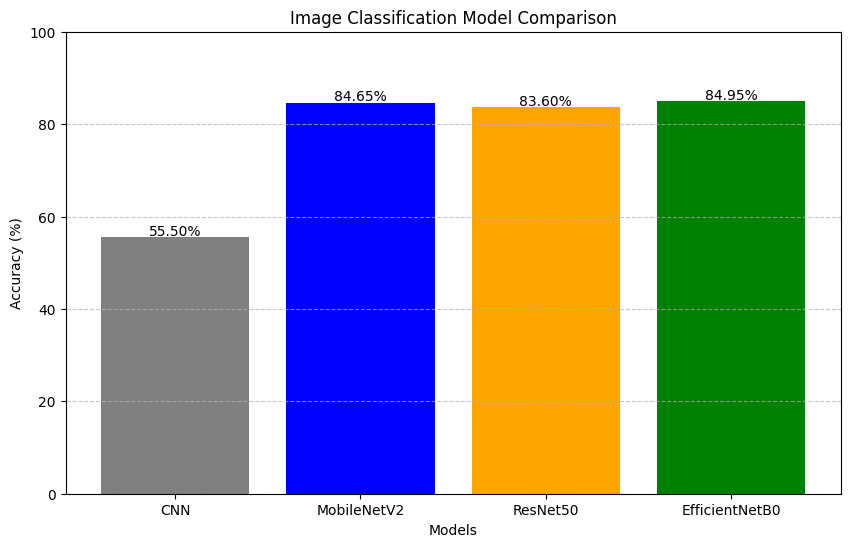

In [6]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =====================================================
# LOAD CIFAR-10 DATASET
# =====================================================
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use subset to reduce memory usage and prevent timeouts
X_train = X_train[:10000]
y_train = y_train[:10000]
X_test = X_test[:2000]
y_test = y_test[:2000]

# Keep as float32 but do not normalize here to let Preprocessing Layers manage scales
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =====================================================
# CREATE DATASET PIPELINE
# =====================================================
IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

results = {}

# =====================================================
# CUSTOM CNN
# =====================================================
print("\nTraining Custom CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.Rescaling(1./255), # Explicit scaling for the custom CNN
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(train_ds, epochs=5, validation_data=test_ds, verbose=1)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

del cnn
tf.keras.backend.clear_session()
gc.collect()

# =====================================================
# FUNCTION FOR TRANSFER LEARNING MODELS
# =====================================================
def train_pretrained(base_model_fn, prep_layer, model_name):
    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
    base_model.trainable = False

    # Standardized sequential pipeline with custom model-specific normalization layer
    inputs = layers.Input(shape=(96, 96, 3))
    x = prep_layer(inputs) if prep_layer else inputs
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, epochs=3, validation_data=test_ds, verbose=1)

    loss, acc = model.evaluate(test_ds, verbose=0)
    results[model_name] = acc * 100

    del model, base_model
    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================
# MODEL EXECUTION LOOPS WITH CORRECT PREPROCESSING
# =====================================================
# MobileNetV2 requires [-1, 1] scaling
train_pretrained(MobileNetV2, layers.Rescaling(1./127.5, offset=-1.0), "MobileNetV2")

# ResNet50 requires Caffe style BGR scaling (managed cleanly via native module mapping)
train_pretrained(ResNet50, tf.keras.applications.resnet50.preprocess_input, "ResNet50")

# EfficientNetB0 handles rescaling internally inside the model graph layout
train_pretrained(EfficientNetB0, None, "EfficientNetB0")

# =====================================================
# RESULTS & DISPLAY TERMINAL
# =====================================================
print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")
for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

best_model = max(results, key=results.get)
print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model], 2), "%")

# =====================================================
# GRAPH GENERATION
# =====================================================
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['gray', 'blue', 'orange', 'green'])
plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.5, f"{y:.2f}%", ha='center')

plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
